# Credit Card Customer Churn & Risk Segmentation Dashboard

### Question: Which credit card customer segments are most likely to churn, and what account and usage patterns can predict that risk?

### Stakeholder Framing: A bank's customer retention team requires a queryable tool that ranks currently active customers by churn risk so that retention offers can be targeted at the right customers before they leave.

In [4]:
%pip install pandas numpy sqlalchemy matplotlib seaborn flask

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
U

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Project root = the folder this notebook lives in
PROJECT_ROOT = Path.cwd()
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\matte\Local\PortfolioFiles\Customer_Churn_Dashboard


In [6]:
# Create folder structure
for folder in ["data/raw", "db", "etl", "analysis", "app/templates", "app/static"]:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

raw_path = PROJECT_ROOT / "data/raw/BankChurners.csv"

if not raw_path.exists():
    raise FileNotFoundError(
        f"Expected the raw dataset at {raw_path}.\n"
        "Download BankChurners.csv from "
        "https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers "
        "and place it there before continuing."
    )

df_raw = pd.read_csv(raw_path)
print(f"Loaded {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Loaded 10127 rows, 23 columns


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [7]:
# Drop Naive Bayes columns (dataset documentation says not to use)
nb_cols = [c for c in df_raw.columns if c.startswith("Naive_Bayes")]
print(f"Dropping {len(nb_cols)} Naive Bayes columns: {nb_cols}")

df = df_raw.drop(columns=nb_cols)
df.dtypes

Dropping 2 Naive Bayes columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

In [8]:
# Create database schema

%%writefile db/schema.sql
CREATE TABLE IF NOT EXISTS customers (
    client_num          INTEGER PRIMARY KEY,
    attrition_flag        TEXT,
    customer_age            INTEGER,
    gender                    TEXT,
    dependent_count            INTEGER,
    education_level              TEXT,
    marital_status                 TEXT,
    income_category                  TEXT,
    card_category                      TEXT
);

CREATE TABLE IF NOT EXISTS account_activity (
    client_num             INTEGER REFERENCES customers(client_num),
    months_on_book            INTEGER,
    total_relationship_count    INTEGER,
    credit_limit                   REAL,
    total_revolving_bal               REAL,
    avg_open_to_buy                     REAL,
    total_trans_amt                       REAL,
    total_trans_ct                          INTEGER,
    avg_utilization_ratio                     REAL
);

Writing db/schema.sql


In [9]:
# Create schema

db_path = PROJECT_ROOT / "db/churn.db"
engine = create_engine(f"sqlite:///{db_path}")

# Run schema.sql to create the table structure
schema_sql = (PROJECT_ROOT / "db/schema.sql").read_text()
with engine.begin() as conn:
    for statement in schema_sql.split(";"):
        statement = statement.strip()
        if statement:
            conn.execute(text(statement))

print("Schema created.")

Schema created.


In [10]:
# Load data into SQL

customer_cols = ["CLIENTNUM", "Attrition_Flag", "Customer_Age", "Gender",
                  "Dependent_count", "Education_Level", "Marital_Status",
                  "Income_Category", "Card_Category"]
activity_cols = ["CLIENTNUM", "Months_on_book", "Total_Relationship_Count",
                  "Credit_Limit", "Total_Revolving_Bal", "Avg_Open_To_Buy",
                  "Total_Trans_Amt", "Total_Trans_Ct", "Avg_Utilization_Ratio"]

customers = df[customer_cols].rename(columns={
    "CLIENTNUM": "client_num", "Attrition_Flag": "attrition_flag",
    "Customer_Age": "customer_age", "Gender": "gender",
    "Dependent_count": "dependent_count", "Education_Level": "education_level",
    "Marital_Status": "marital_status", "Income_Category": "income_category",
    "Card_Category": "card_category"
})

activity = df[activity_cols].rename(columns={
    "CLIENTNUM": "client_num", "Months_on_book": "months_on_book",
    "Total_Relationship_Count": "total_relationship_count",
    "Credit_Limit": "credit_limit", "Total_Revolving_Bal": "total_revolving_bal",
    "Avg_Open_To_Buy": "avg_open_to_buy", "Total_Trans_Amt": "total_trans_amt",
    "Total_Trans_Ct": "total_trans_ct", "Avg_Utilization_Ratio": "avg_utilization_ratio"
})

customers.to_sql("customers", engine, if_exists="append", index=False)
activity.to_sql("account_activity", engine, if_exists="append", index=False)

print(f"Loaded {len(customers)} rows into customers")
print(f"Loaded {len(activity)} rows into account_activity")

Loaded 10127 rows into customers
Loaded 10127 rows into account_activity


In [11]:
# Feature engineering in SQL

%%writefile etl/create_view.sql
DROP VIEW IF EXISTS customer_risk_features;

CREATE VIEW customer_risk_features AS
SELECT
    c.client_num,
    c.attrition_flag,
    c.customer_age,
    c.income_category,
    c.card_category,
    a.months_on_book,
    a.credit_limit,
    a.total_trans_ct,
    a.total_trans_amt,
    a.avg_utilization_ratio,
    a.total_relationship_count
FROM customers c
JOIN account_activity a ON c.client_num = a.client_num;

Writing etl/create_view.sql


In [12]:
view_sql = (PROJECT_ROOT / "etl/create_view.sql").read_text()
with engine.begin() as conn:
    for statement in view_sql.split(";"):
        statement = statement.strip()
        if statement:
            conn.execute(text(statement))

features = pd.read_sql("SELECT * FROM customer_risk_features", engine)
print(f"{len(features)} rows in the joined feature view")
features.head()

10127 rows in the joined feature view


,client_num,attrition_flag,customer_age,income_category,card_category,months_on_book,credit_limit,total_trans_ct,total_trans_amt,avg_utilization_ratio,total_relationship_count
0,768805383,Existing Customer,45,$60K - $80K,Blue,39,12691.0,42,1144.0,0.061,5
1,818770008,Existing Customer,49,Less than $40K,Blue,44,8256.0,33,1291.0,0.105,6
2,713982108,Existing Customer,51,$80K - $120K,Blue,36,3418.0,20,1887.0,0.000,4
3,769911858,Existing Customer,40,Less than $40K,Blue,34,3313.0,20,1171.0,0.760,3
4,709106358,Existing Customer,40,$60K - $80K,Blue,21,4716.0,28,816.0,0.000,5


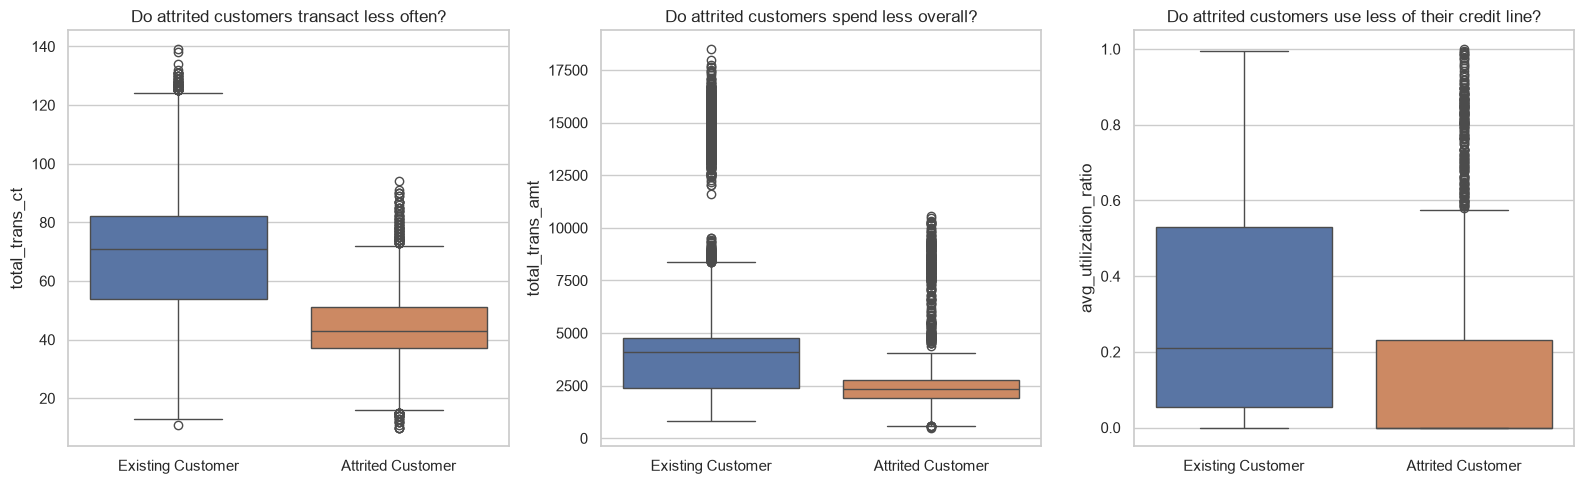

In [13]:
# Churn Risk Analysis
# Comparing attrited vs existing customers

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=features, x="attrition_flag", y="total_trans_ct", ax=axes[0], hue="attrition_flag", legend=False)
axes[0].set_title("Do attrited customers transact less often?")
axes[0].set_xlabel("")

sns.boxplot(data=features, x="attrition_flag", y="total_trans_amt", ax=axes[1], hue="attrition_flag", legend=False)
axes[1].set_title("Do attrited customers spend less overall?")
axes[1].set_xlabel("")

sns.boxplot(data=features, x="attrition_flag", y="avg_utilization_ratio", ax=axes[2], hue="attrition_flag", legend=False)
axes[2].set_title("Do attrited customers use less of their credit line?")
axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "analysis_eda_comparison.png", dpi=150)
plt.show()

### Analysis Note: Attrited customers have visibly lower transaction counts, spend less overall and use less of their credit line.

In [14]:
# Build risk score

features["trans_ct_percentile"] = features["total_trans_ct"].rank(pct=True)
features["utilization_percentile"] = features["avg_utilization_ratio"].rank(pct=True)

W_TRANS_CT = 0.6
W_UTILIZATION = 0.4

features["churn_risk_score"] = (
    (1 - features["trans_ct_percentile"]) * W_TRANS_CT +
    (1 - features["utilization_percentile"]) * W_UTILIZATION
)

features[["client_num", "attrition_flag", "total_trans_ct", "avg_utilization_ratio", "churn_risk_score"]].head()

,client_num,attrition_flag,total_trans_ct,avg_utilization_ratio,churn_risk_score
0,768805383,Existing Customer,42,0.061,0.743705
1,818770008,Existing Customer,33,0.105,0.779905
2,713982108,Existing Customer,20,0.000,0.944683
3,769911858,Existing Customer,20,0.760,0.620756
4,709106358,Existing Customer,28,0.000,0.921398


Average churn_risk_score by actual outcome:
attrition_flag
Attrited Customer    0.712
Existing Customer    0.459
Name: churn_risk_score, dtype: float64


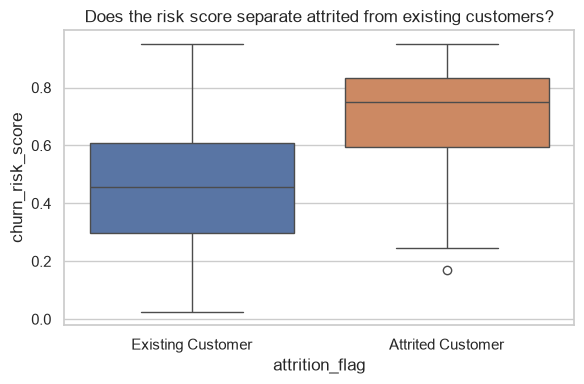

In [15]:
# Validation of risk score

validation = features.groupby("attrition_flag")["churn_risk_score"].mean().round(3)
print("Average churn_risk_score by actual outcome:")
print(validation)

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=features, x="attrition_flag", y="churn_risk_score", hue="attrition_flag", legend=False, ax=ax)
ax.set_title("Does the risk score separate attrited from existing customers?")
plt.tight_layout()
plt.show()

In [16]:
# Risk score table to SQL

features.to_sql("customer_scores", engine, if_exists="replace", index=False)
print("Saved customer_scores table.")

Saved customer_scores table.


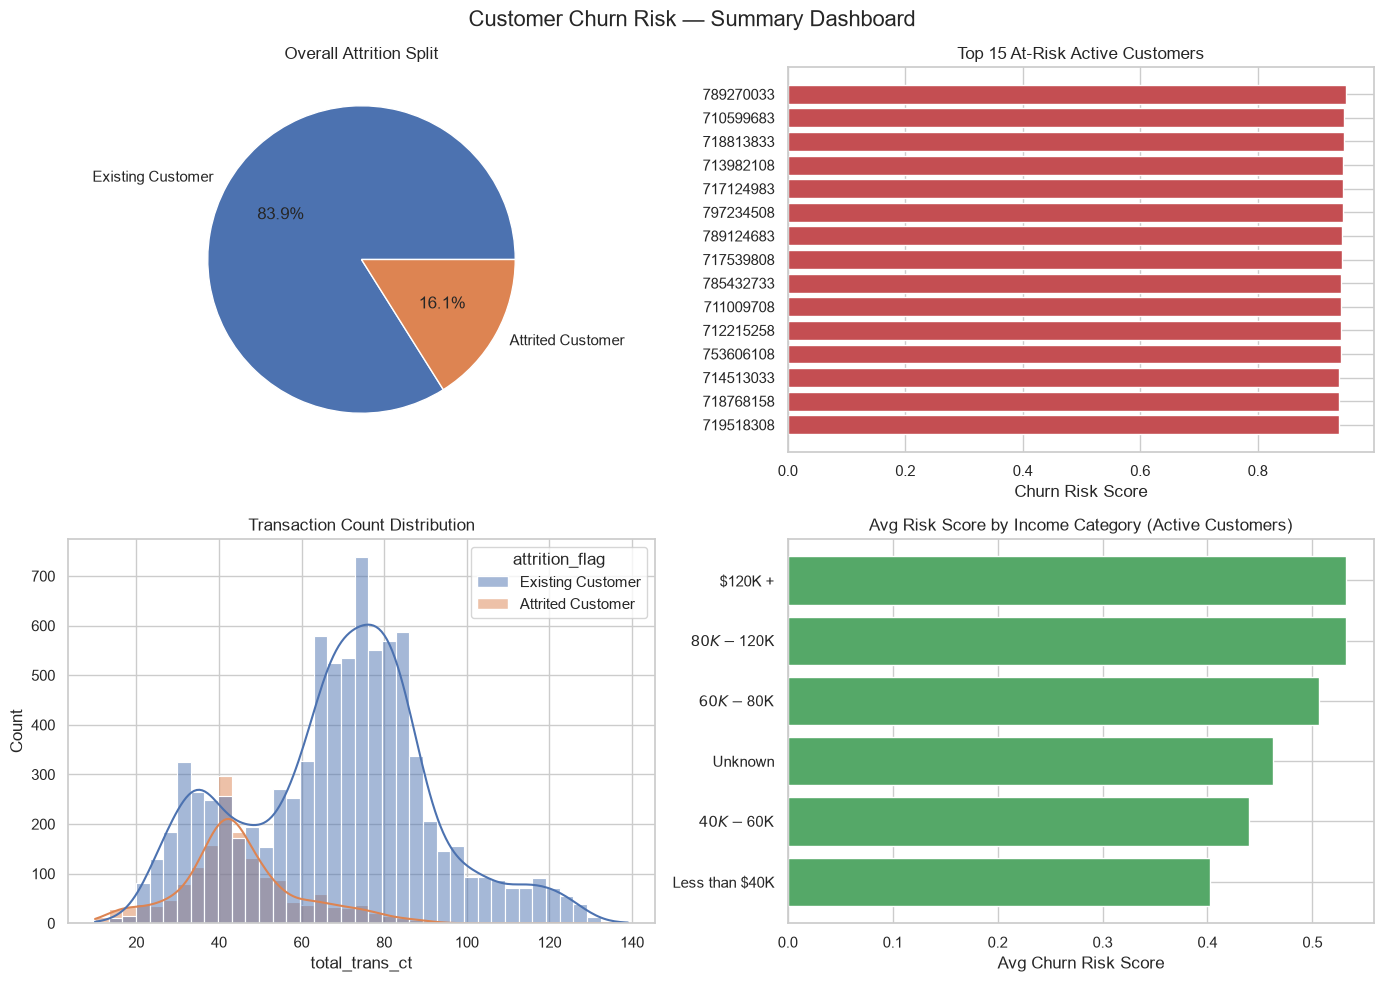

In [17]:
# Summary dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Customer Churn Risk — Summary Dashboard", fontsize=16)

# Top-left: attrition rate overall
attrition_counts = features["attrition_flag"].value_counts()
axes[0, 0].pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%",
               colors=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Overall Attrition Split")

# Top-right: top 15 highest-risk ACTIVE customers
active_customers = features[features["attrition_flag"] == "Existing Customer"]
top15 = active_customers.nlargest(15, "churn_risk_score")
axes[0, 1].barh(top15["client_num"].astype(str), top15["churn_risk_score"], color="#C44E52")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top 15 At-Risk Active Customers")
axes[0, 1].set_xlabel("Churn Risk Score")

# Bottom-left: transaction count distribution by attrition flag
sns.histplot(data=features, x="total_trans_ct", hue="attrition_flag", kde=True, ax=axes[1, 0], legend=True)
axes[1, 0].set_title("Transaction Count Distribution")

# Bottom-right: risk score by income category (active customers only)
income_risk = active_customers.groupby("income_category")["churn_risk_score"].mean().sort_values()
axes[1, 1].barh(income_risk.index, income_risk.values, color="#55A868")
axes[1, 1].set_title("Avg Risk Score by Income Category (Active Customers)")
axes[1, 1].set_xlabel("Avg Churn Risk Score")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "analysis_summary_dashboard.png", dpi=150)
plt.show()

In [18]:
# Flask app for dashboard

%%writefile app/app.py
from pathlib import Path

from flask import Flask, jsonify, render_template
from sqlalchemy import create_engine
import pandas as pd

APP_DIR = Path(__file__).resolve().parent
DB_PATH = APP_DIR.parent / "db" / "churn.db"

app = Flask(__name__)
engine = create_engine(f"sqlite:///{DB_PATH}")


@app.route("/")
def index():
    return render_template("index.html")


@app.route("/api/top-risk-customers")
def top_risk_customers():
    df = pd.read_sql(
        "SELECT * FROM customer_scores WHERE attrition_flag = 'Existing Customer' "
        "ORDER BY churn_risk_score DESC LIMIT 25", engine)
    return jsonify(df.to_dict(orient="records"))


@app.route("/api/summary-stats")
def summary_stats():
    df = pd.read_sql(
        "SELECT attrition_flag, COUNT(*) as customer_count, "
        "AVG(total_trans_ct) as avg_trans_ct, AVG(avg_utilization_ratio) as avg_utilization "
        "FROM customer_scores GROUP BY attrition_flag", engine)
    return jsonify(df.to_dict(orient="records"))


if __name__ == "__main__":
    app.run(debug=True)

Writing app/app.py


In [19]:
# HTML index for dashboard

%%writefile app/templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Customer Churn Risk Dashboard</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
    <script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
</head>
<body>
    <header>
        <h1>Customer Churn Risk Dashboard</h1>
        <p>Credit card customer retention — active customers ranked by churn risk</p>
    </header>

    <section class="summary-cards" id="summaryCards"></section>

    <section class="chart-section">
        <h2>Top 15 At-Risk Active Customers</h2>
        <canvas id="riskChart" height="100"></canvas>
    </section>

    <section class="table-section">
        <h2>At-Risk Customer Detail</h2>
        <table id="riskTable">
            <thead>
                <tr>
                    <th>Client #</th>
                    <th>Age</th>
                    <th>Income Category</th>
                    <th>Card Category</th>
                    <th>Trans. Count</th>
                    <th>Utilization</th>
                    <th>Risk Score</th>
                </tr>
            </thead>
            <tbody></tbody>
        </table>
    </section>

    <script src="{{ url_for('static', filename='dashboard.js') }}"></script>
</body>
</html>

Writing app/templates/index.html


In [20]:
# CSS for dashboard

%%writefile app/static/style.css
* { box-sizing: border-box; }

body {
    font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
    background: #f7f8fa;
    color: #222;
    margin: 0;
    padding: 0 24px 48px;
}

header {
    padding: 32px 0 16px;
    border-bottom: 1px solid #e2e4e8;
    margin-bottom: 24px;
}

header h1 {
    margin: 0 0 4px;
    font-size: 1.6rem;
}

header p {
    margin: 0;
    color: #666;
}

.summary-cards {
    display: flex;
    gap: 16px;
    margin-bottom: 32px;
    flex-wrap: wrap;
}

.card {
    background: white;
    border: 1px solid #e2e4e8;
    border-radius: 8px;
    padding: 16px 20px;
    min-width: 180px;
}

.card .label {
    font-size: 0.8rem;
    color: #777;
    text-transform: uppercase;
    letter-spacing: 0.03em;
}

.card .value {
    font-size: 1.5rem;
    font-weight: 600;
    margin-top: 4px;
    color: #C44E52;
}

.chart-section, .table-section {
    background: white;
    border: 1px solid #e2e4e8;
    border-radius: 8px;
    padding: 20px 24px;
    margin-bottom: 24px;
}

table {
    width: 100%;
    border-collapse: collapse;
    font-size: 0.9rem;
}

th, td {
    text-align: left;
    padding: 8px 10px;
    border-bottom: 1px solid #eee;
}

th {
    cursor: pointer;
    color: #444;
    user-select: none;
}

th:hover {
    color: #C44E52;
}

Writing app/static/style.css


In [21]:
# javascript for dashboard

%%writefile app/static/dashboard.js
async function fetchJSON(url) {
    const res = await fetch(url);
    return res.json();
}

function renderSummaryCards(summary) {
    const container = document.getElementById("summaryCards");
    const existing = summary.find(d => d.attrition_flag === "Existing Customer") || {};
    const attrited = summary.find(d => d.attrition_flag === "Attrited Customer") || {};
    const totalCustomers = (existing.customer_count || 0) + (attrited.customer_count || 0);
    const attritionRate = totalCustomers ? ((attrited.customer_count || 0) / totalCustomers * 100).toFixed(1) : "0";

    const cards = [
        { label: "Total Customers", value: totalCustomers },
        { label: "Attrition Rate", value: `${attritionRate}%` },
        { label: "Avg Trans. Count (Existing)", value: (existing.avg_trans_ct || 0).toFixed(1) },
        { label: "Avg Trans. Count (Attrited)", value: (attrited.avg_trans_ct || 0).toFixed(1) },
    ];

    container.innerHTML = cards.map(c => `
        <div class="card">
            <div class="label">${c.label}</div>
            <div class="value">${c.value}</div>
        </div>
    `).join("");
}

function renderRiskChart(customers) {
    const ctx = document.getElementById("riskChart");
    new Chart(ctx, {
        type: "bar",
        data: {
            labels: customers.map(c => c.client_num),
            datasets: [{
                label: "Churn Risk Score",
                data: customers.map(c => c.churn_risk_score),
                backgroundColor: "#C44E52"
            }]
        },
        options: {
            responsive: true,
            plugins: { legend: { display: false } },
            scales: { x: { ticks: { autoSkip: false, maxRotation: 60 } } }
        }
    });
}

function renderTable(customers) {
    const tbody = document.querySelector("#riskTable tbody");
    tbody.innerHTML = customers.map(c => `
        <tr>
            <td>${c.client_num}</td>
            <td>${c.customer_age}</td>
            <td>${c.income_category}</td>
            <td>${c.card_category}</td>
            <td>${c.total_trans_ct}</td>
            <td>${(c.avg_utilization_ratio ?? 0).toFixed(2)}</td>
            <td>${c.churn_risk_score.toFixed(3)}</td>
        </tr>
    `).join("");
}

(async function init() {
    const [summary, topRisk] = await Promise.all([
        fetchJSON("/api/summary-stats"),
        fetchJSON("/api/top-risk-customers")
    ]);
    renderSummaryCards(summary);
    renderRiskChart(topRisk.slice(0, 15));
    renderTable(topRisk);
})();

Writing app/static/dashboard.js


## To Run the Web Dashboard

1. Open a terminal in this project's root folder.
2. Run:
   ```bash
   python app/app.py
   ```
3. Open **http://127.0.0.1:5000** in your browser.

You can keep re-running this notebook to refresh `db/churn.db` with new data or a revised risk score — the Flask app will pick up the changes on its next request since it reads the SQL tables live, no restart needed for data changes (only for code changes in `app.py` itself).